1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
dataset/test_images\1.jpg → Невідомо (впевненість: 0.49)


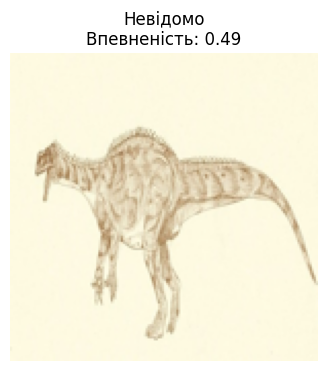

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
dataset/test_images\2.jpg → Динозавр (впевненість: 1.00)


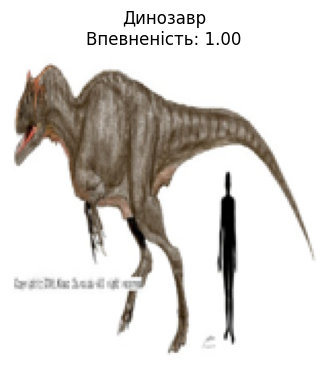

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
dataset/test_images\3.jpg → Динозавр (впевненість: 1.00)


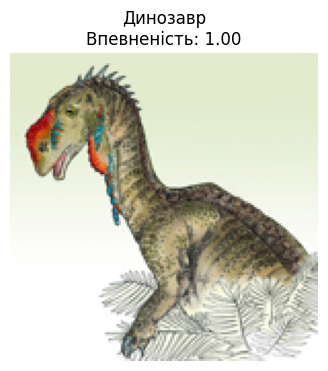

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
dataset/test_images\4.jpg → Динозавр (впевненість: 1.00)


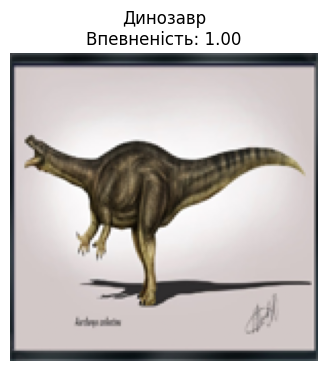

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
dataset/test_images\5.jpg → Динозавр (впевненість: 1.00)


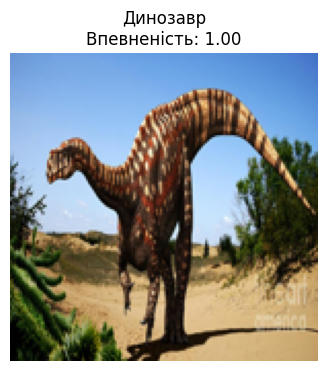

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
dataset/test_images\bird.jpeg → Не динозавр (впевненість: 0.07)


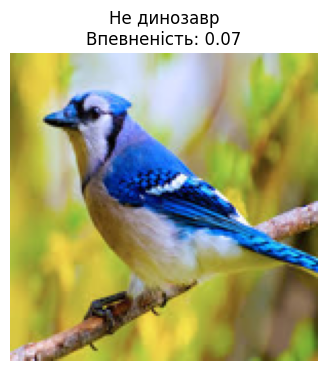

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
dataset/test_images\car.jpeg → Не динозавр (впевненість: 0.05)


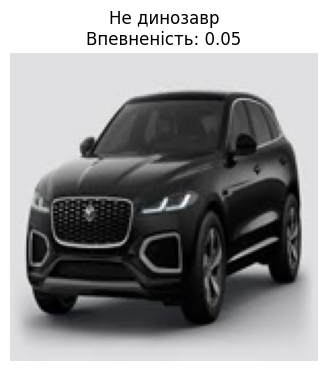

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
dataset/test_images\cat.jpeg → Не динозавр (впевненість: 0.05)


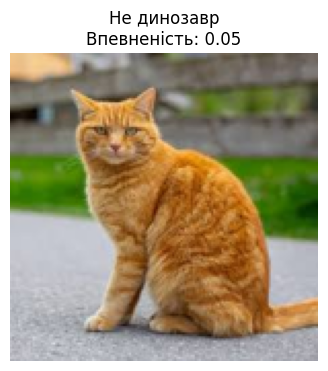

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
dataset/test_images\deer.jpeg → Динозавр (впевненість: 0.96)


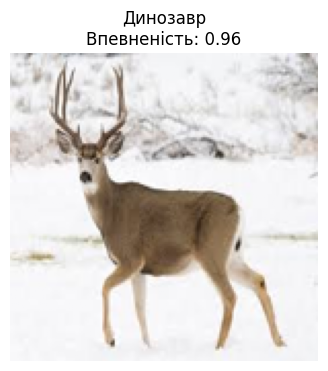

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
dataset/test_images\dog.jpeg → Не динозавр (впевненість: 0.10)


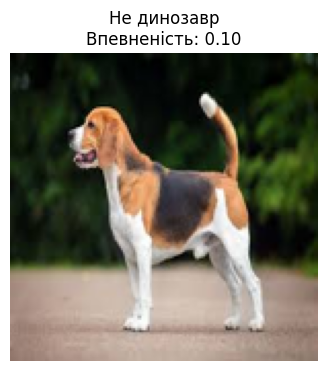

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
dataset/test_images\frog.jpeg → Динозавр (впевненість: 0.75)


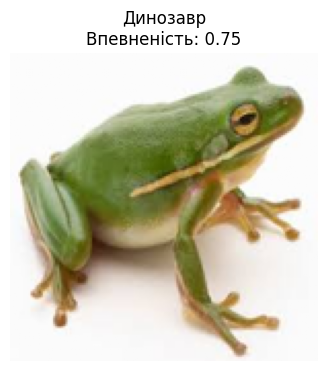

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
dataset/test_images\horse.jpeg → Динозавр (впевненість: 1.00)


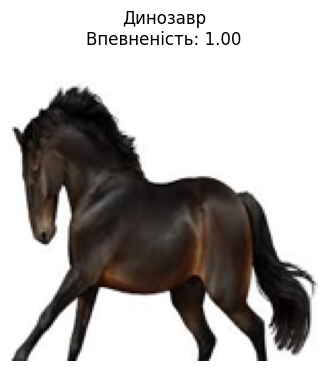

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
dataset/test_images\plane.jpeg → Не динозавр (впевненість: 0.28)


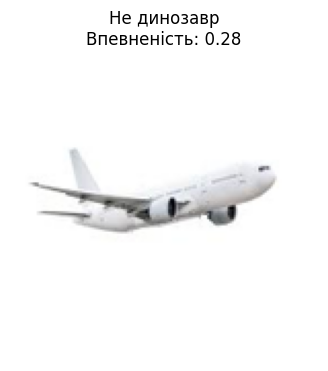

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
dataset/test_images\ship.jpeg → Не динозавр (впевненість: 0.00)


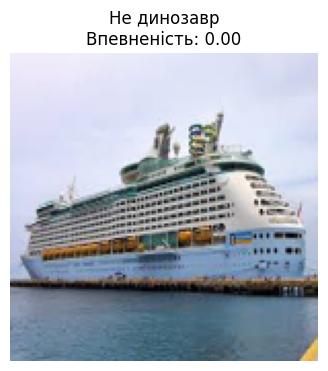

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
dataset/test_images\truck.jpeg → Не динозавр (впевненість: 0.04)


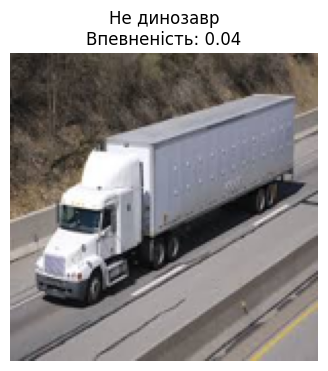

In [1]:
import glob
from PIL import Image
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from config import MODEL_PATH, IMG_SIZE

model = load_model(MODEL_PATH)
# model = load_model("test_new_model.h5")

class_names = {0: "Не динозавр", 1: "Динозавр"}

threshold_low = 0.4  
threshold_high = 0.6  

test_paths = glob.glob("dataset/test_images/*.*") 

for path in test_paths:
    img_orig = Image.open(path).convert("RGB").resize(IMG_SIZE)
    img_array = np.array(img_orig).astype("float32") / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_input)[0][0]

    if pred < threshold_low:
        label = "Не динозавр"
    elif pred > threshold_high:
        label = "Динозавр"
    else:
        label = "Невідомо"

    print(f"{path} → {label} (впевненість: {pred:.2f})")

    plt.figure(figsize=(4,4))
    plt.imshow(img_array)
    plt.axis("off")
    plt.title(f"{label}\nВпевненість: {pred:.2f}", fontsize=12)
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


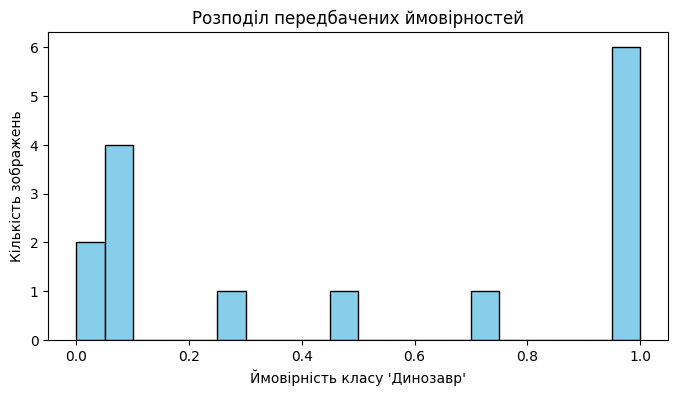

In [2]:
import matplotlib.pyplot as plt

pred_probs = []

for path in test_paths:
    img_orig = Image.open(path).convert("RGB").resize(IMG_SIZE)
    img_array = np.array(img_orig).astype("float32") / 255.0
    img_input = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_input)[0][0]
    pred_probs.append(pred)

plt.figure(figsize=(8,4))
plt.hist(pred_probs, bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Ймовірність класу 'Динозавр'")
plt.ylabel("Кількість зображень")
plt.title("Розподіл передбачених ймовірностей")
plt.show()
